In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from matplotlib.ticker import PercentFormatter

In [2]:
import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython.display import display, Markdown, Math
import numpy as np
from scipy.stats import norm
from scipy.stats import chi2_contingency
import src.analysis_utils as analysis_utils

/Users/zhiwen.mo/Desktop/ironhack/week5/vanguard-ab-test/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/zhiwen.mo/Desktop/ironhack/week5/vanguard-ab-test/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureW

In [3]:
df_transition = load_data.load("transition")
df_transition.head()

transition table loaded!


,client_id,variation,visit_seq,step_rank,next_rank,step_diff,date_time,transition_type
0,555,Test,1,1,2.0,1.0,2017-04-15 12:57:56+00:00,forward
1,555,Test,2,2,3.0,1.0,2017-04-15 12:58:03+00:00,forward
2,555,Test,3,3,4.0,1.0,2017-04-15 12:58:35+00:00,forward
3,555,Test,4,4,5.0,1.0,2017-04-15 13:00:14+00:00,forward
4,555,Test,5,5,NaN,NaN,2017-04-15 13:00:34+00:00,end


In [64]:
transition_pct = df_transition.groupby('variation')['transition_type'].value_counts(normalize=True).reset_index()
transition_pct

,variation,transition_type,proportion
0,Control,forward,0.605482
1,Control,end,0.167445
2,Control,same_step,0.129291
3,Control,backward,0.093962
4,Control,skip,0.003821
5,Test,forward,0.589183
6,Test,end,0.152621
7,Test,same_step,0.145072
8,Test,backward,0.107635
9,Test,skip,0.005490


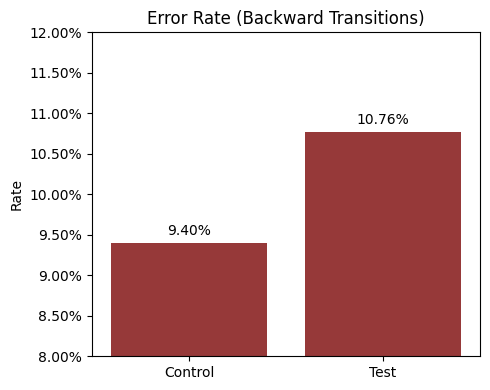

In [63]:
error_rate = (
    transition_pct[
        transition_pct['transition_type'] == 'backward'
    ]
)

fig, ax = plt.subplots(figsize=(5,4))

sns.barplot(
    data=error_rate,
    x='variation',
    y='proportion',
    color='#A52A2A',
    ax=ax
)

for i, value in enumerate(error_rate['proportion']):
    ax.text(
        i,
        value + 0.001,
        f'{value:.2%}',
        ha='center'
    )

ax.yaxis.set_major_formatter(PercentFormatter(1))

# 压缩Y轴
ax.set_ylim(0.08, 0.12)

plt.title('Error Rate (Backward Transitions)')
plt.ylabel('Rate')
plt.xlabel('')

plt.tight_layout()
plt.show()

## Client end visit on which step?

In [45]:
#client end visit on which step?
df_end = df_transition[df_transition['transition_type']=='end']
end_table = pd.crosstab(
    df_end['variation'],
    df_end['step_rank']
)
end_pct = end_table.div(
    end_table.sum(axis=1),
    axis=0
)
end_pct.reset_index()
end_pct.columns.name = None
end_pct.reset_index()
end_pct.to_csv("../data/tableau/end_pct.csv")
end_pct

,1,2,3,4,5
variation,,,,,
Control,0.237209,0.094510,0.031192,0.052354,0.584736
Test,0.206801,0.061258,0.021210,0.037155,0.673576


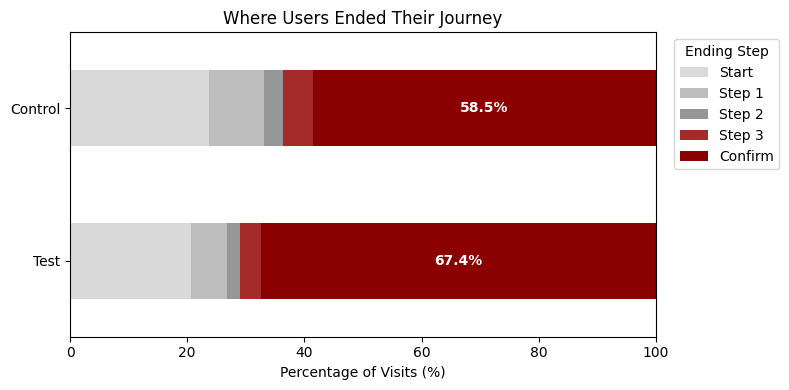

In [47]:
plot_df = (end_pct * 100).rename(
    columns={
        1:'Start',
        2:'Step 1',
        3:'Step 2',
        4:'Step 3',
        5:'Confirm'
    }
)

plot_df = plot_df.loc[['Test', 'Control']]

ax = plot_df.plot(
    kind='barh',
    stacked=True,
    figsize=(8,4),
    color=[
        '#D9D9D9',
        '#BDBDBD',
        '#969696',
        '#A52A2A',
        '#8B0000'
    ]
)

for i, value in enumerate(plot_df['Confirm']):
    plt.text(
        100 - value/2,
        i,
        f'{value:.1f}%',
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.xlim(0,100)

plt.title('Where Users Ended Their Journey')
plt.xlabel('Percentage of Visits (%)')
plt.ylabel('')

plt.legend(
    title='Ending Step',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

End-step analysis shows that a substantially larger share of Test visits reached the Confirm stage before ending (67.4% vs. 58.5%). At the same time, visits ending at earlier stages declined across the entire funnel.

The largest reductions occurred at the Start and Step 1 stages, suggesting that the redesigned process was particularly effective at reducing early-stage abandonment.

These findings indicate that the improved completion rate was driven not by changes at a single step, but by consistently lower drop-off throughout the user journey.

## On which step client go backward?

In [49]:
#Backward distribution
df_back = df_transition[df_transition['transition_type']=='backward']
back_table = pd.crosstab(
    df_back['variation'],
    df_back['step_rank']
)
back_pct = back_table.div(
    back_table.sum(axis=1),
    axis=0
)


back_pct.columns.name = None
back_pct.reset_index()
back_pct.to_csv("../data/tableau/back_pct.csv")
back_table

,2,3,4,5
variation,,,,
Control,3552,2748,5103,1802
Test,7586,5293,5417,723


In [33]:
#Backtrack Rate
step_total = pd.crosstab(
    df_transition['variation'],
    df_transition['step_rank']
)

backtrack_rate = (
    back_table
    .div(step_total)
    .fillna(0)
)
backtrack_rate.to_csv("../data/tableau/backtrack_rate.csv")
backtrack_rate

step_rank,1,2,3,4,5
variation,,,,,
Control,0.0,0.120227,0.106623,0.226770,0.103946
Test,0.0,0.196193,0.171300,0.210279,0.028242


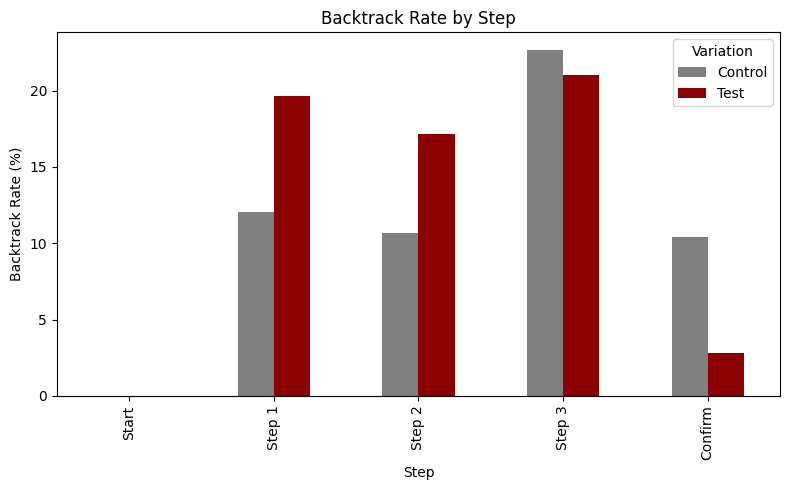

In [30]:
plot_df = (backtrack_rate * 100).rename(
    columns={
        1: 'Start',
        2: 'Step 1',
        3: 'Step 2',
        4: 'Step 3',
        5: 'Confirm'
    }
)

plot_df.T.plot(
    kind='bar',
    figsize=(8,5),
    color=['gray', '#8B0000']
)

plt.title('Backtrack Rate by Step')
plt.ylabel('Backtrack Rate (%)')
plt.xlabel('Step')
plt.legend(title='Variation')

plt.tight_layout()
plt.show()

Backtrack rate analysis revealed a notable shift in user behavior across the redesigned journey.

Compared with the Control group, users in the Test group were significantly more likely to revisit previous steps during the early stages of the process. The backtrack rate increased from 12.0% to 19.6% at Step 1 and from 10.7% to 17.1% at Step 2.

In contrast, the backtrack rate at the Confirm stage decreased substantially from 10.4% to 2.8%, representing a reduction of approximately 73%.

These results suggest that users in the redesigned experience reviewed and corrected information earlier in the journey rather than waiting until the final confirmation stage.

While the Test group exhibited more backtracking overall during the initial steps, users were considerably less likely to return and modify information after reaching the Confirm stage. This indicates that uncertainties were resolved earlier in the process, reducing the need for last-minute revisions before submission.